# 03 — Predictive Statistical Modelling (Task 5)

Brief section 6. Two prediction problems on the customer-level table (features from before the 9 Sep 2011 cutoff,
targets from the following 90 days):

* **Repurchase (binary):** logistic regression baseline, then forward/backward stepwise vs LASSO vs elastic net.
* **Future spend (continuous):** linear regression on log spend vs a Gamma GLM with a log link.

Evaluation goes beyond accuracy: AUC, calibration curve and Brier score, top-decile lift, an expected-profit comparison,
and RMSE/MAE for the spend models. Assumption checks: VIF, linearity of the logit, residual diagnostics, influential observations.

**Run notebook 00 first** (it creates `data/processed/customer_table.csv`).

In [1]:
import sys
sys.path.append('../..')
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv('../../data/processed/customer_table.csv')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, brier_score_loss, mean_squared_error, mean_absolute_error
import statsmodels.api as sm

## Stage 1 — Split and transform

Log-transform the right-skewed features (`log1p` = log(1+x), defined at 0), then split into train/test with the
repurchase rate preserved (`stratify`). `CustomerID` and `FutureSpend` are deliberately excluded from the features
(`FutureSpend` would leak the answer). The test set stays untouched until the final comparison.

In [3]:
df = customers.copy()

for col in ['Frequency', 'Monetary', 'DistinctProducts', 'AvgBasketValue']:
    df[f'log_{col}'] = np.log1p(df[col])

CONT = ['Recency', 'TenureDays', 'CancellationRate',
        'log_Frequency', 'log_Monetary', 'log_DistinctProducts', 'log_AvgBasketValue']
BINARY = ['IsUK', 'AcquiredInQ4']
MODEL_FEATURES = CONT + BINARY

train, test = train_test_split(df, test_size=0.25, random_state=42, stratify=df['Repurchase'])
y_train, y_test = train['Repurchase'], test['Repurchase']
print('Repurchase rate  train:', round(y_train.mean(), 4), ' test:', round(y_test.mean(), 4))
print('n train:', len(train), ' n test:', len(test))

Repurchase rate  train: 0.4336  test: 0.4338
n train: 3939  n test: 1314


In [4]:
# Standardise continuous features (fit on train only, so no test information leaks in).
# Odds ratios then read as 'per +1 standard deviation', which makes features comparable.
scaler = StandardScaler().fit(train[CONT])

def prep(d):
    X = d[MODEL_FEATURES].copy()
    X[CONT] = scaler.transform(d[CONT])
    return X

Xs_train, Xs_test = prep(train), prep(test)

## Stage 2 — Logistic regression baseline (odds ratios)

Odds ratio > 1: higher odds of repurchase per +1 SD of that feature. < 1: lower odds. If the confidence interval
contains 1, the effect is not clearly different from zero.

In [5]:
Xtr = sm.add_constant(Xs_train)
Xte = sm.add_constant(Xs_test)
logit = sm.Logit(y_train, Xtr).fit(disp=0)
print(logit.summary())

                           Logit Regression Results                           
Dep. Variable:             Repurchase   No. Observations:                 3939
Model:                          Logit   Df Residuals:                     3929
Method:                           MLE   Df Model:                            9
Date:                Wed, 23 Sep 2026   Pseudo R-squ.:                  0.2138
Time:                        14:05:19   Log-Likelihood:                -2119.2
converged:                       True   LL-Null:                       -2695.5
Covariance Type:            nonrobust   LLR p-value:                2.152e-242
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.4288      0.130     -3.286      0.001      -0.684      -0.173
Recency                 -0.5817      0.064     -9.074      0.000      -0.707      -0.456
TenureDays  

In [6]:
or_table = pd.DataFrame({
    'odds_ratio': np.exp(logit.params),
    'ci_low': np.exp(logit.conf_int()[0]),
    'ci_high': np.exp(logit.conf_int()[1]),
    'p_value': logit.pvalues,
}).drop('const').round(3)
or_table

,odds_ratio,ci_low,ci_high,p_value
Recency,0.559,0.493,0.634,0.000
TenureDays,0.745,0.661,0.839,0.000
CancellationRate,1.073,0.995,1.157,0.068
log_Frequency,3.476,1.425,8.483,0.006
log_Monetary,0.514,0.152,1.736,0.284
log_DistinctProducts,1.307,1.167,1.463,0.000
log_AvgBasketValue,1.564,0.812,3.010,0.181
IsUK,0.967,0.746,1.254,0.800
AcquiredInQ4,1.409,1.196,1.661,0.000


In [7]:
print('Test AUC (unpenalised logistic):', round(roc_auc_score(y_test, logit.predict(Xte)), 4))

Test AUC (unpenalised logistic): 0.8091


## Stage 3 — Assumption checks

### 3a. Multicollinearity (VIF)

VIF shows how well one predictor can be predicted from the others. Above 5 is a concern, above 10 is serious.
High values make coefficients unstable, which motivates LASSO / elastic net.

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.Series([variance_inflation_factor(Xtr.values, i) for i in range(1, Xtr.shape[1])],
                index=Xtr.columns[1:]).sort_values(ascending=False)
vif.round(2)

log_Monetary            202.98
log_Frequency            97.95
log_AvgBasketValue       58.86
Recency                   3.01
TenureDays                2.87
log_DistinctProducts      2.30
AcquiredInQ4              1.09
CancellationRate          1.07
IsUK                      1.05
dtype: float64

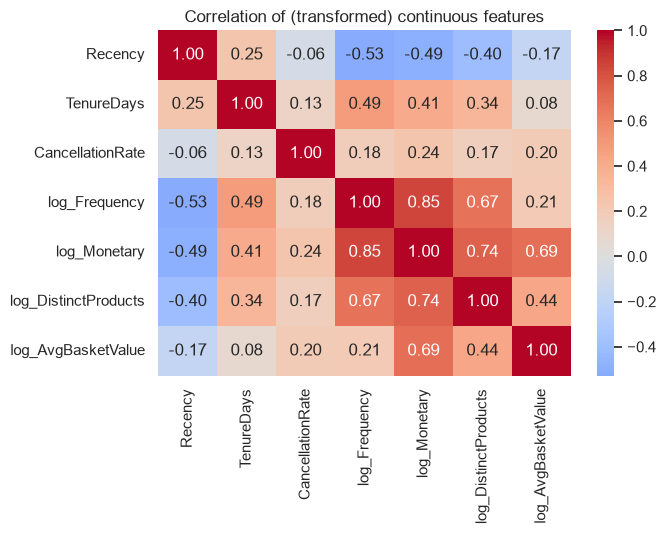

In [9]:
corr = train[CONT].corr()
plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation of (transformed) continuous features')
plt.tight_layout()
plt.savefig('../../reports/figures/pred_feature_correlation.png', dpi=150, bbox_inches='tight')

### 3b. Linearity of the logit

Logistic regression assumes each continuous feature is linearly related to the **log-odds** of repurchase.
Visual check: bin each feature into deciles and plot the empirical log-odds against the bin mean (should look roughly
straight). Formal check: Box–Tidwell adds an `x·ln(x)` term per feature; a significant term signals non-linearity.

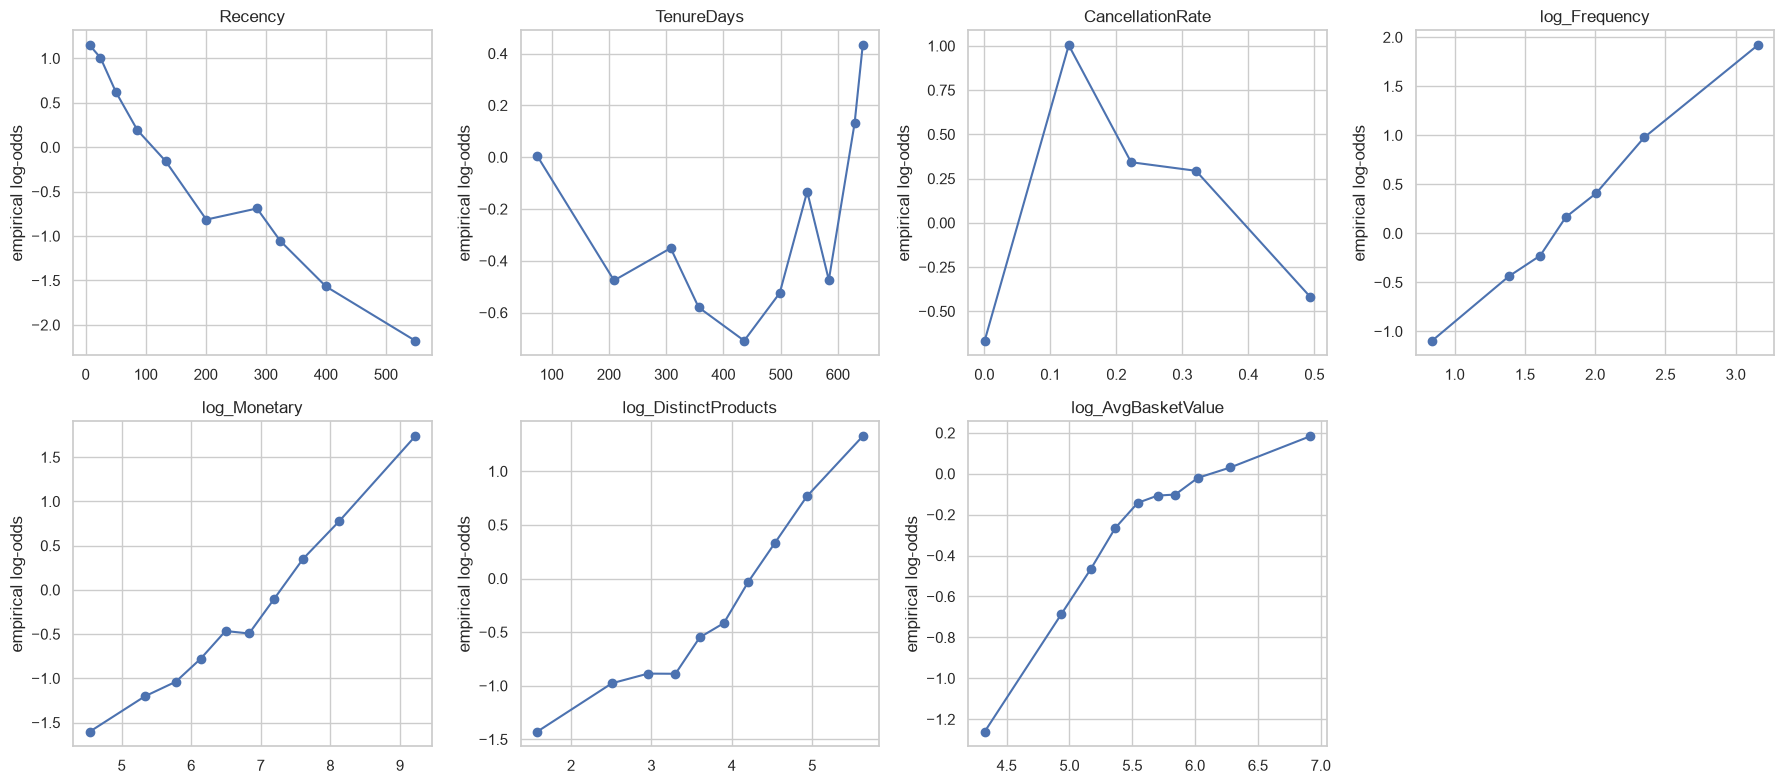

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for ax, v in zip(axes, CONT):
    b = pd.qcut(train[v], 10, duplicates='drop')
    g = train.groupby(b, observed=True).agg(x=(v, 'mean'), rate=('Repurchase', 'mean'))
    rate = g['rate'].clip(0.01, 0.99)
    ax.plot(g['x'], np.log(rate / (1 - rate)), marker='o')
    ax.set_title(v)
    ax.set_ylabel('empirical log-odds')
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('../../reports/figures/pred_linearity_logit.png', dpi=150, bbox_inches='tight')

In [11]:
# Box-Tidwell needs strictly positive values: shift the two features that contain 0 by +1.
# CancellationRate is zero-inflated (most customers have 0), so it is excluded from this test.
bt_vars = ['Recency', 'TenureDays', 'log_Frequency', 'log_Monetary', 'log_DistinctProducts', 'log_AvgBasketValue']
Xbt = train[MODEL_FEATURES].copy()
Xbt['Recency'] += 1
Xbt['TenureDays'] += 1
for v in bt_vars:
    Xbt[f'{v}_xlnx'] = Xbt[v] * np.log(Xbt[v])

bt = sm.Logit(y_train, sm.add_constant(Xbt)).fit(disp=0, maxiter=200)
bt_table = pd.DataFrame({'coef': bt.params, 'p_value': bt.pvalues}).loc[[f'{v}_xlnx' for v in bt_vars]].round(4)
bt_table['non-linear at 5%?'] = bt_table['p_value'] < 0.05
bt_table

,coef,p_value,non-linear at 5%?
Recency_xlnx,0.0018,0.0060,True
TenureDays_xlnx,0.0005,0.4879,False
log_Frequency_xlnx,-0.5072,0.6623,False
log_Monetary_xlnx,0.7869,0.0687,False
log_DistinctProducts_xlnx,-0.0255,0.8790,False
log_AvgBasketValue_xlnx,-0.4813,0.4076,False


### 3c. Influential observations (Cook's distance)

A few customers can dominate a fit. Notebook 01 showed some huge orders that were later cancelled, which inflate `Monetary`
for those customers. Check which customers are most influential and whether removing them changes the coefficients.

In [12]:
glm_bin = sm.GLM(y_train, Xtr, family=sm.families.Binomial()).fit()
cooks = pd.Series(glm_bin.get_influence().cooks_distance[0], index=train.index).sort_values(ascending=False)
print('Rule-of-thumb threshold 4/n =', round(4 / len(train), 5), '| customers above it:', int((cooks > 4 / len(train)).sum()))

top = cooks.head(10)
train.loc[top.index, ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Repurchase']].assign(cooks_d=top.round(4))

Rule-of-thumb threshold 4/n = 0.00102 | customers above it: 154


,CustomerID,Recency,Frequency,Monetary,Repurchase,cooks_d
3622,16454.0,519,1,1.55,1,0.0080
4509,17448.0,437,41,14448.67,0,0.0061
418,12835.0,335,41,5996.83,0,0.0048
3889,16754.0,280,29,65500.07,0,0.0047
2846,15581.0,64,34,4505.16,0,0.0041
377,12789.0,420,2,148.50,1,0.0039
2866,15603.0,556,1,40.00,1,0.0038
165,12531.0,594,1,1645.98,1,0.0037
3010,15768.0,23,34,15308.89,0,0.0036
4599,17557.0,640,1,34.00,1,0.0036


In [13]:
drop_idx = cooks.head(5).index
train_ex = train.drop(drop_idx)
logit_ex = sm.Logit(train_ex['Repurchase'], sm.add_constant(prep(train_ex))).fit(disp=0)
shift = pd.DataFrame({'all data': logit.params, 'without top-5 influential': logit_ex.params})
shift['abs change'] = (shift['all data'] - shift['without top-5 influential']).abs()
print('Max absolute coefficient change after removing the 5 most influential customers:', round(shift['abs change'].max(), 3))
shift.round(3)

Max absolute coefficient change after removing the 5 most influential customers: 0.231


,all data,without top-5 influential,abs change
const,-0.429,-0.425,0.003
Recency,-0.582,-0.559,0.023
TenureDays,-0.294,-0.314,0.020
CancellationRate,0.070,0.068,0.003
log_Frequency,1.246,1.465,0.219
log_Monetary,-0.666,-0.897,0.231
log_DistinctProducts,0.268,0.267,0.000
log_AvgBasketValue,0.447,0.583,0.136
IsUK,-0.034,-0.027,0.007
AcquiredInQ4,0.343,0.344,0.001


## Stage 4 — Stepwise vs LASSO vs Elastic net logistic regression

* **Stepwise (forward / backward, by AIC):** adds or drops one feature at a time. Simple and interpretable, but it is a greedy
  search, can be unstable, and its p-values ignore the selection step.
* **LASSO (L1):** shrinks coefficients and sets some exactly to zero. With correlated features it tends to pick one and drop the others.
* **Elastic net (L1 + L2):** mixes both penalties. Correlated features are shrunk together instead of arbitrarily dropped.

The penalty strength (and the L1/L2 mix for elastic net) is chosen by 5-fold cross-validation on the **training** set using log-loss,
a proper scoring rule that rewards well-calibrated probabilities (not just ranking).

In [14]:
def aic_of(features):
    if not features:
        return sm.Logit(y_train, np.ones((len(train), 1))).fit(disp=0).aic
    return sm.Logit(y_train, sm.add_constant(Xs_train[features])).fit(disp=0).aic

def forward_stepwise(cands):
    selected, best = [], aic_of([])
    while True:
        trials = {f: aic_of(selected + [f]) for f in cands if f not in selected}
        if not trials:
            break
        f, a = min(trials.items(), key=lambda kv: kv[1])
        if a < best - 1e-9:
            selected.append(f); best = a
        else:
            break
    return selected, best

def backward_stepwise(cands):
    selected = list(cands); best = aic_of(selected)
    while len(selected) > 1:
        trials = {f: aic_of([g for g in selected if g != f]) for f in selected}
        f, a = min(trials.items(), key=lambda kv: kv[1])
        if a < best - 1e-9:
            selected.remove(f); best = a
        else:
            break
    return selected, best

### Forward stepwise

In [15]:
fwd_feats, fwd_aic = forward_stepwise(MODEL_FEATURES)
fwd_res = sm.Logit(y_train, sm.add_constant(Xs_train[fwd_feats])).fit(disp=0)
print('Forward  selected:', fwd_feats, '| AIC', round(fwd_aic, 1))
print('Full model AIC   :', round(logit.aic, 1))

Forward  selected: ['Recency', 'log_Frequency', 'log_DistinctProducts', 'TenureDays', 'AcquiredInQ4', 'log_AvgBasketValue', 'CancellationRate'] | AIC 4255.7
Full model AIC   : 4258.4


### Backward stepwise

In [16]:
bwd_feats, bwd_aic = backward_stepwise(MODEL_FEATURES)
bwd_res = sm.Logit(y_train, sm.add_constant(Xs_train[bwd_feats])).fit(disp=0)
print('Backward selected:', bwd_feats, '| AIC', round(bwd_aic, 1))

Backward selected: ['Recency', 'TenureDays', 'CancellationRate', 'log_Frequency', 'log_DistinctProducts', 'log_AvgBasketValue', 'AcquiredInQ4'] | AIC 4255.7


### LASSO (L1)

In [17]:
lasso = LogisticRegressionCV(Cs=20, l1_ratios=[1.0], solver='saga', cv=5, scoring='neg_log_loss',
                             max_iter=5000, random_state=42, use_legacy_attributes=False).fit(Xs_train, y_train)
print('LASSO chosen C =', round(float(lasso.C_), 4))

LASSO chosen C = 0.6158


### Elastic net (L1 + L2)

In [18]:
enet = LogisticRegressionCV(Cs=20, l1_ratios=[0.1, 0.3, 0.5, 0.7, 0.9], solver='saga', cv=5, scoring='neg_log_loss',
                            max_iter=5000, random_state=42, use_legacy_attributes=False).fit(Xs_train, y_train)
print('Elastic net chosen C =', round(float(enet.C_), 4), '| l1_ratio =', float(enet.l1_ratio_))

Elastic net chosen C = 0.6158 | l1_ratio = 0.9


### Ridge (L2 only)

The brief lists Ridge regression as an example Task 5 technique. Unlike LASSO, Ridge shrinks every coefficient toward zero but never sets one exactly to zero - it handles the correlated RFM features by keeping and shrinking all of them together, rather than arbitrarily dropping one.

In [19]:
ridge = LogisticRegressionCV(Cs=20, l1_ratios=[0.0], solver='saga', cv=5, scoring='neg_log_loss',
                             max_iter=5000, random_state=42, use_legacy_attributes=False).fit(Xs_train, y_train)
print('Ridge chosen C =', round(float(ridge.C_), 4))

Ridge chosen C = 1.6238


### Best subset selection

With only 9 candidate features, evaluating every possible subset (2^9 - 1 = 511 non-empty combinations) by AIC is computationally trivial - unlike the review-level model in the reference literature with 30+ predictors, where best subset is infeasible and regularisation/stepwise are the only practical options.

In [20]:
import itertools

best_subset_aic, best_subset_feats = np.inf, None
for k in range(1, len(MODEL_FEATURES) + 1):
    for combo in itertools.combinations(MODEL_FEATURES, k):
        aic = sm.Logit(y_train, sm.add_constant(Xs_train[list(combo)])).fit(disp=0).aic
        if aic < best_subset_aic:
            best_subset_aic, best_subset_feats = aic, list(combo)

print('Best subset selected:', best_subset_feats)
print('Best subset AIC:', round(best_subset_aic, 1), '(all 511 non-empty subsets evaluated)')
best_subset_res = sm.Logit(y_train, sm.add_constant(Xs_train[best_subset_feats])).fit(disp=0)

Best subset selected: ['Recency', 'TenureDays', 'CancellationRate', 'log_Frequency', 'log_DistinctProducts', 'log_AvgBasketValue', 'AcquiredInQ4']
Best subset AIC: 4255.7 (all 511 non-empty subsets evaluated)


In [21]:
coefs = pd.DataFrame({
    'Logistic (no penalty)': logit.params.drop('const'),
    'Forward stepwise': fwd_res.params.drop('const'),
    'Backward stepwise': bwd_res.params.drop('const'),
    'LASSO': pd.Series(lasso.coef_.ravel(), index=MODEL_FEATURES),
    'Elastic net': pd.Series(enet.coef_.ravel(), index=MODEL_FEATURES),
    'Ridge': pd.Series(ridge.coef_.ravel(), index=MODEL_FEATURES),
    'Best subset': best_subset_res.params.drop('const'),
}).reindex(MODEL_FEATURES).fillna(0.0)
print('Coefficients on standardised features; 0.000 = feature dropped by that method')
coefs.round(3)

Coefficients on standardised features; 0.000 = feature dropped by that method


,Logistic (no penalty),Forward stepwise,Backward stepwise,LASSO,Elastic net,Ridge,Best subset
Recency,-0.582,-0.569,-0.569,-0.571,-0.571,-0.577,-0.569
TenureDays,-0.294,-0.314,-0.314,-0.306,-0.306,-0.301,-0.314
CancellationRate,0.070,0.069,0.069,0.067,0.067,0.070,0.069
log_Frequency,1.246,0.767,0.767,0.758,0.759,1.029,0.767
log_Monetary,-0.666,0.000,0.000,0.000,0.000,-0.369,0.000
log_DistinctProducts,0.268,0.259,0.259,0.258,0.259,0.265,0.259
log_AvgBasketValue,0.447,0.094,0.094,0.092,0.092,0.289,0.094
IsUK,-0.034,0.000,0.000,-0.004,-0.007,-0.032,0.000
AcquiredInQ4,0.343,0.355,0.355,0.342,0.343,0.347,0.355


## Stage 5 — Evaluation beyond accuracy (test set)

| Metric | Question it answers |
|---|---|
| AUC | Does the model rank likely repurchasers above non-repurchasers? |
| Brier score / calibration curve | Can the predicted probabilities be trusted as probabilities? (needed for the profit rule) |
| Top-decile lift | How much better is targeting the top 10% than picking customers at random? |
| Expected profit | What is a targeting strategy actually worth in money? |

A "Recency rank" heuristic (contact the most recently active customers) is included as a naive benchmark that needs no model.

In [22]:
probs = {
    'Logistic': np.asarray(logit.predict(Xte)),
    'Forward stepwise': np.asarray(fwd_res.predict(sm.add_constant(Xs_test[fwd_feats]))),
    'Backward stepwise': np.asarray(bwd_res.predict(sm.add_constant(Xs_test[bwd_feats]))),
    'LASSO': lasso.predict_proba(Xs_test)[:, 1],
    'Elastic net': enet.predict_proba(Xs_test)[:, 1],
    'Ridge': ridge.predict_proba(Xs_test)[:, 1],
    'Best subset': np.asarray(best_subset_res.predict(sm.add_constant(Xs_test[best_subset_feats]))),
}
scores = {**probs, 'Recency rank (heuristic)': -test['Recency'].values}
yt = y_test.values

def top_decile_lift(y, s, frac=0.10):
    k = int(np.ceil(len(y) * frac))
    idx = np.argsort(-np.asarray(s))[:k]
    return y[idx].mean() / y.mean()

metrics = pd.DataFrame({
    'AUC': {n: roc_auc_score(yt, s) for n, s in scores.items()},
    'Brier': {n: brier_score_loss(yt, p) for n, p in probs.items()},
    'Top-decile lift': {n: top_decile_lift(yt, s) for n, s in scores.items()},
}).round(4)
print('Brier of a constant prediction (base rate):', round(yt.mean() * (1 - yt.mean()), 4), '(lower is better)')
metrics

Brier of a constant prediction (base rate): 0.2456 (lower is better)


,AUC,Brier,Top-decile lift
Logistic,0.8091,0.1752,2.0957
Forward stepwise,0.8099,0.1750,2.1132
Backward stepwise,0.8099,0.1750,2.1132
LASSO,0.8099,0.1750,2.0957
Elastic net,0.8099,0.1750,2.0957
Ridge,0.8095,0.1751,2.0957
Best subset,0.8099,0.1750,2.1132
Recency rank (heuristic),0.7636,NaN,1.7813


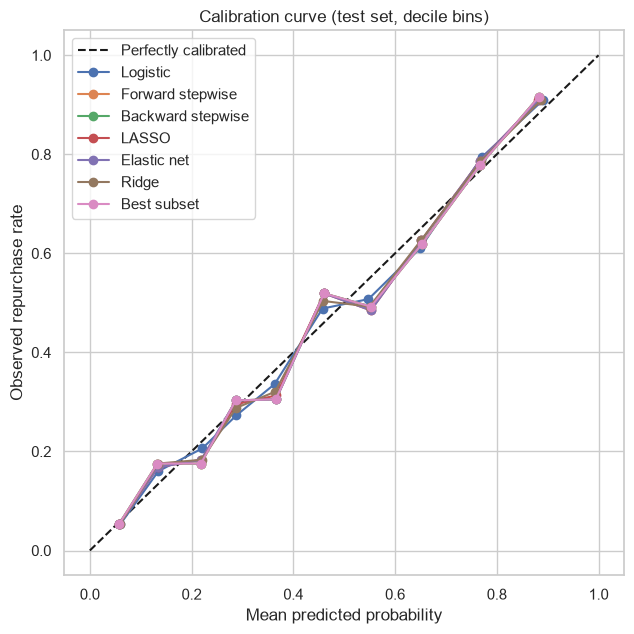

In [23]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
for name, p in probs.items():
    frac_pos, mean_pred = calibration_curve(yt, p, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=name)
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed repurchase rate')
ax.set_title('Calibration curve (test set, decile bins)')
ax.legend()
plt.tight_layout()
plt.savefig('../../reports/figures/pred_calibration.png', dpi=150, bbox_inches='tight')

,customers,repurchase_rate,lift
decile,,,
1,132,0.909,2.096
2,131,0.786,1.813
3,131,0.626,1.443
4,132,0.485,1.118
5,131,0.519,1.197
6,131,0.305,0.704
7,132,0.303,0.699
8,131,0.183,0.422
9,131,0.168,0.387


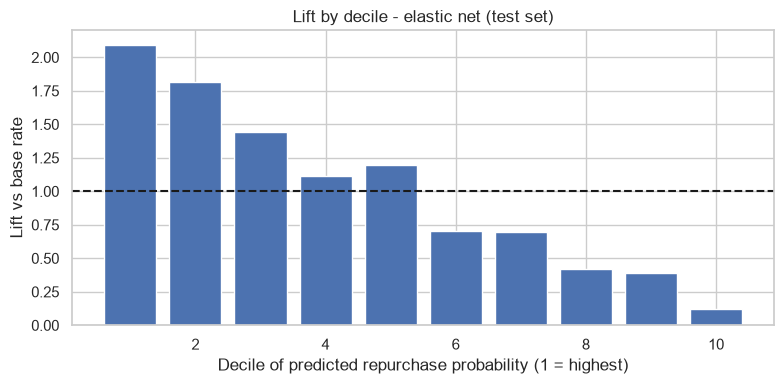

In [24]:
p_en = probs['Elastic net']
rank = pd.Series(p_en).rank(method='first', ascending=False)
decile = pd.qcut(rank, 10, labels=range(1, 11))
lift_tbl = pd.DataFrame({'y': yt, 'decile': decile}).groupby('decile', observed=True).agg(
    customers=('y', 'size'), repurchase_rate=('y', 'mean'))
lift_tbl['lift'] = lift_tbl['repurchase_rate'] / yt.mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(lift_tbl.index.astype(int), lift_tbl['lift'])
ax.axhline(1, color='k', ls='--')
ax.set_xlabel('Decile of predicted repurchase probability (1 = highest)')
ax.set_ylabel('Lift vs base rate')
ax.set_title('Lift by decile - elastic net (test set)')
plt.tight_layout()
plt.savefig('../../reports/figures/pred_lift.png', dpi=150, bbox_inches='tight')
lift_tbl.round(3)

### Expected-profit comparison

The brief's decision rule is: contact a customer only if the expected margin from their repurchase exceeds the cost of the offer.
We have no experiment yet (Task 6 proposes one), so the **incremental effect of an offer is unknown**. The three parameters below are
**placeholder assumptions** and must be replaced with figures from the client or the expert interview (Task 11):

* `MARGIN` — profit margin on revenue,
* `OFFER_COST` — cost of contacting one customer (£),
* `INCREMENTAL` — share of a contacted customer's future spend that the offer is responsible for.

Profit of targeting a customer = `INCREMENTAL × MARGIN × FutureSpend − OFFER_COST`, using each test customer's **realised** spend.
We rank customers by each model's score and accumulate profit as we contact more of them.

,profit @ top 10%,best profit,% contacted at best,profit contacting everyone
Logistic,9358.00000,11629.0,33.0,6476.0000
Forward stepwise,9310.00000,11592.0,38.0,6476.0000
Backward stepwise,9310.00000,11592.0,38.0,6476.0000
LASSO,9297.00000,11566.0,33.0,6476.0000
Elastic net,9297.00000,11566.0,33.0,6476.0000
Ridge,9297.00000,11596.0,33.0,6476.0000
Best subset,9310.00000,11592.0,38.0,6476.0000
Recency rank (heuristic),6824.00000,10564.0,45.0,6476.0000
Random targeting (10%),650.59057,NaN,NaN,6476.3334


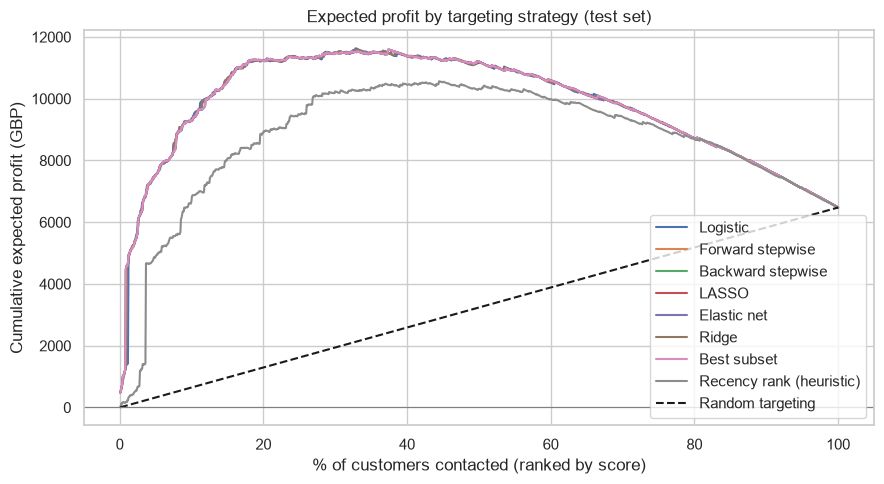

In [25]:
MARGIN = 0.30
OFFER_COST = 10.0
INCREMENTAL = 0.10

spend_test = test['FutureSpend'].values

def profit_curve(score, spend, margin=MARGIN, cost=OFFER_COST, inc=INCREMENTAL):
    order = np.argsort(-np.asarray(score))
    return np.cumsum(inc * margin * spend[order] - cost)

n = len(test)
x = np.arange(1, n + 1) / n * 100
curves = {name: profit_curve(s, spend_test) for name, s in scores.items()}
random_curve = np.arange(1, n + 1) * (INCREMENTAL * MARGIN * spend_test.mean() - OFFER_COST)

plt.figure(figsize=(9, 5))
for name, c in curves.items():
    plt.plot(x, c, label=name)
plt.plot(x, random_curve, 'k--', label='Random targeting')
plt.axhline(0, color='grey', lw=0.8)
plt.xlabel('% of customers contacted (ranked by score)')
plt.ylabel('Cumulative expected profit (GBP)')
plt.title('Expected profit by targeting strategy (test set)')
plt.legend()
plt.tight_layout()
plt.savefig('../../reports/figures/pred_profit_curve.png', dpi=150, bbox_inches='tight')

k10 = int(np.ceil(0.10 * n))
profit_tbl = pd.DataFrame({
    'profit @ top 10%': {name: c[k10 - 1] for name, c in curves.items()},
    'best profit': {name: c.max() for name, c in curves.items()},
    '% contacted at best': {name: (c.argmax() + 1) / n * 100 for name, c in curves.items()},
    'profit contacting everyone': {name: c[-1] for name, c in curves.items()},
}).round(0)
profit_tbl.loc['Random targeting (10%)'] = [random_curve[k10 - 1], np.nan, np.nan, random_curve[-1]]
profit_tbl

In [26]:
sens = pd.DataFrame(
    {f'incremental={inc:.0%}': {f'cost=GBP {c:g}': profit_curve(p_en, spend_test, cost=c, inc=inc)[k10 - 1]
                                for c in [5, 10, 20]} for inc in [0.05, 0.10, 0.20]}
).round(0)
print('Elastic net, profit when contacting the top 10% under different assumptions:')
sens

Elastic net, profit when contacting the top 10% under different assumptions:


,incremental=5%,incremental=10%,incremental=20%
cost=GBP 5,4648.0,9957.0,20573.0
cost=GBP 10,3988.0,9297.0,19913.0
cost=GBP 20,2668.0,7977.0,18593.0


## Stage 6 — Future spend models

`FutureSpend` is 0 for customers who did not repurchase (about 57%), and a Gamma GLM is only defined for **positive** outcomes.
So the spend models are fitted on **repurchasers only** and answer "how much will they spend *given that they return*?".
Combined with the repurchase probability this gives an expected spend per customer: `P(repurchase) × E[spend | repurchase]`.

* **Linear regression on log(spend):** assumes log-spend is normal with constant variance. Predictions on the £ scale must be
  back-transformed, and `exp(prediction)` underestimates the mean, so Duan's smearing factor is applied.
* **Gamma GLM, log link:** models the £ spend directly, allows variance to grow with the mean, and keeps predictions positive.

Repurchasers  train: 1708  test: 570


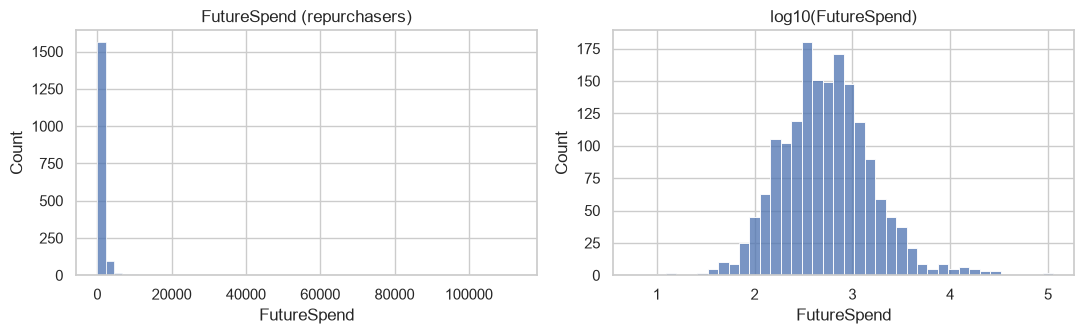

In [27]:
rep_tr = train[train['Repurchase'] == 1]
rep_te = test[test['Repurchase'] == 1]
Xr_tr = sm.add_constant(prep(rep_tr))
Xr_te = sm.add_constant(prep(rep_te))
ys_tr, ys_te = rep_tr['FutureSpend'], rep_te['FutureSpend']
print('Repurchasers  train:', len(rep_tr), ' test:', len(rep_te))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(ys_tr, bins=50, ax=axes[0]); axes[0].set_title('FutureSpend (repurchasers)')
sns.histplot(np.log10(ys_tr), bins=40, ax=axes[1]); axes[1].set_title('log10(FutureSpend)')
plt.tight_layout()
plt.savefig('../../reports/figures/pred_spend_distribution.png', dpi=150, bbox_inches='tight')

In [28]:
ols = sm.OLS(np.log(ys_tr), Xr_tr).fit()
smear = np.mean(np.exp(ols.resid))
pred_ols = np.exp(ols.predict(Xr_te)) * smear

gam = sm.GLM(ys_tr, Xr_tr, family=sm.families.Gamma(link=sm.families.links.Log())).fit()
pred_gam = gam.predict(Xr_te)

def rmse(a, b): return float(np.sqrt(mean_squared_error(a, b)))

naive = np.full(len(ys_te), ys_tr.mean())
spend_metrics = pd.DataFrame({
    'RMSE (GBP)': {'OLS on log spend (smeared)': rmse(ys_te, pred_ols), 'Gamma GLM (log link)': rmse(ys_te, pred_gam),
                   'Predict the mean': rmse(ys_te, naive)},
    'MAE (GBP)': {'OLS on log spend (smeared)': mean_absolute_error(ys_te, pred_ols),
                  'Gamma GLM (log link)': mean_absolute_error(ys_te, pred_gam),
                  'Predict the mean': mean_absolute_error(ys_te, naive)},
    'Median abs error (GBP)': {'OLS on log spend (smeared)': float(np.median(np.abs(ys_te - pred_ols))),
                               'Gamma GLM (log link)': float(np.median(np.abs(ys_te - pred_gam))),
                               'Predict the mean': float(np.median(np.abs(ys_te - naive)))},
}).round(1)
print('Duan smearing factor:', round(smear, 3), '| Gamma dispersion (scale):', round(gam.scale, 3))
spend_metrics

Duan smearing factor: 1.601 | Gamma dispersion (scale): 2.352


,RMSE (GBP),MAE (GBP),Median abs error (GBP)
OLS on log spend (smeared),3513.1,697.5,374.7
Gamma GLM (log link),4492.6,969.9,512.6
Predict the mean,4702.9,1093.6,819.0


In [29]:
effects = pd.DataFrame({
    'OLS: x spend per +1 SD': np.exp(ols.params),
    'Gamma: x spend per +1 SD': np.exp(gam.params),
    'Gamma p-value': gam.pvalues,
}).drop('const').round(3)
effects

,OLS: x spend per +1 SD,Gamma: x spend per +1 SD,Gamma p-value
Recency,1.097,1.007,0.928
TenureDays,0.821,0.508,0.000
CancellationRate,1.012,0.949,0.201
log_Frequency,4.771,3.796,0.000
log_Monetary,0.245,0.414,0.106
log_DistinctProducts,0.933,0.973,0.643
log_AvgBasketValue,3.859,1.622,0.099
IsUK,1.021,0.899,0.420
AcquiredInQ4,1.024,1.058,0.497


### Residual diagnostics and influence

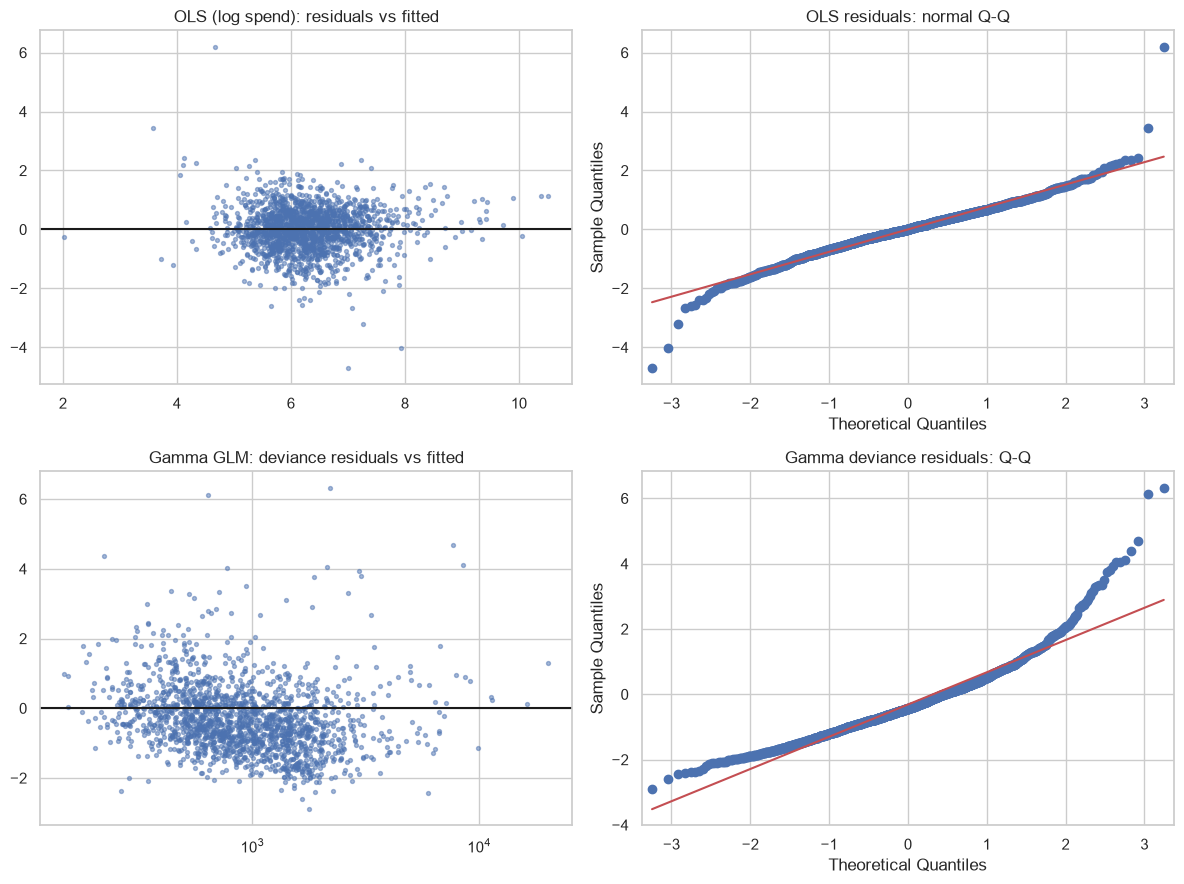

In [30]:
from statsmodels.graphics.gofplots import qqplot

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0, 0].scatter(ols.fittedvalues, ols.resid, s=8, alpha=0.5)
axes[0, 0].axhline(0, color='k'); axes[0, 0].set_title('OLS (log spend): residuals vs fitted')
qqplot(ols.resid, line='s', ax=axes[0, 1]); axes[0, 1].set_title('OLS residuals: normal Q-Q')
axes[1, 0].scatter(gam.fittedvalues, gam.resid_deviance, s=8, alpha=0.5)
axes[1, 0].set_xscale('log'); axes[1, 0].axhline(0, color='k'); axes[1, 0].set_title('Gamma GLM: deviance residuals vs fitted')
qqplot(gam.resid_deviance, line='s', ax=axes[1, 1]); axes[1, 1].set_title('Gamma deviance residuals: Q-Q')
plt.tight_layout()
plt.savefig('../../reports/figures/pred_spend_diagnostics.png', dpi=150, bbox_inches='tight')

In [31]:
cooks_g = pd.Series(gam.get_influence().cooks_distance[0], index=rep_tr.index).sort_values(ascending=False)
topg = cooks_g.head(8)
print('Gamma GLM: 8 most influential repurchasers (Cook\'s distance)')
rep_tr.loc[topg.index, ['CustomerID', 'Frequency', 'Monetary', 'FutureSpend']].assign(cooks_d=topg.round(4))

Gamma GLM: 8 most influential repurchasers (Cook's distance)


,CustomerID,Frequency,Monetary,FutureSpend,cooks_d
1529,14096.0,2,97.43,53161.00,8.7063
5085,18102.0,112,456780.49,112721.01,1.8521
1987,14607.0,9,8048.63,14526.50,1.2511
2022,14646.0,115,425343.12,101157.80,1.0802
1523,14088.0,10,39052.88,24983.92,0.6824
11,12357.0,1,11229.99,6207.67,0.5526
2766,15484.0,2,1061.69,2916.16,0.4977
3827,16684.0,45,114372.71,32770.06,0.2883


### Putting the two halves together: expected spend for every customer

`Expected spend = P(repurchase) x E[spend | repurchase]`, using the elastic-net probability and the Gamma GLM. This is evaluated on **all** test customers
(including the ones who did not return, whose true spend is 0).

In [32]:
cond_spend = np.asarray(gam.predict(Xte))
exp_spend = p_en * cond_spend
mean_pred = np.full(len(test), train['FutureSpend'].mean())

overall = pd.DataFrame({
    'RMSE (GBP)': {'P x Gamma expected spend': rmse(spend_test, exp_spend), 'Predict the mean': rmse(spend_test, mean_pred)},
    'MAE (GBP)': {'P x Gamma expected spend': mean_absolute_error(spend_test, exp_spend),
                  'Predict the mean': mean_absolute_error(spend_test, mean_pred)},
    'Correlation with actual': {'P x Gamma expected spend': float(np.corrcoef(spend_test, exp_spend)[0, 1]),
                                'Predict the mean': np.nan},
}).round(2)
overall

,RMSE (GBP),MAE (GBP),Correlation with actual
P x Gamma expected spend,2985.17,518.41,0.33
Predict the mean,3148.78,678.08,NaN


,profit @ top 10%,best profit,% contacted at best
Rank by P(repurchase),9297.0,11566.0,33.0
Rank by expected spend (P x Gamma),8416.0,11123.0,34.0


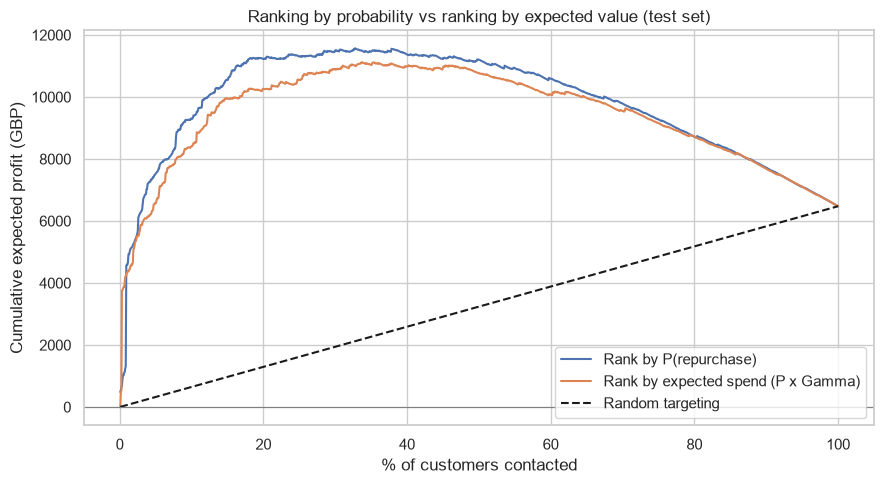

In [33]:
value_score = exp_spend
curves2 = {'Rank by P(repurchase)': profit_curve(p_en, spend_test),
           'Rank by expected spend (P x Gamma)': profit_curve(value_score, spend_test)}

plt.figure(figsize=(9, 5))
for name, c in curves2.items():
    plt.plot(x, c, label=name)
plt.plot(x, random_curve, 'k--', label='Random targeting')
plt.axhline(0, color='grey', lw=0.8)
plt.xlabel('% of customers contacted'); plt.ylabel('Cumulative expected profit (GBP)')
plt.title('Ranking by probability vs ranking by expected value (test set)')
plt.legend(); plt.tight_layout()
plt.savefig('../../reports/figures/pred_profit_value_rank.png', dpi=150, bbox_inches='tight')

pd.DataFrame({name: {'profit @ top 10%': c[k10 - 1], 'best profit': c.max(), '% contacted at best': (c.argmax() + 1) / n * 100}
              for name, c in curves2.items()}).T.round(0)

## Stage 7 — Model comparison summary

In [34]:
summary = metrics.join(profit_tbl[['profit @ top 10%', 'best profit']], how='left')
summary['features kept'] = pd.Series({
    'Logistic': len(MODEL_FEATURES),
    'Forward stepwise': len(fwd_feats),
    'Backward stepwise': len(bwd_feats),
    'LASSO': int((lasso.coef_.ravel() != 0).sum()),
    'Elastic net': int((enet.coef_.ravel() != 0).sum()),
    'Ridge': len(MODEL_FEATURES),
    'Best subset': len(best_subset_feats),
})
summary

,AUC,Brier,Top-decile lift,profit @ top 10%,best profit,features kept
Logistic,0.8091,0.1752,2.0957,9358.0,11629.0,9.0
Forward stepwise,0.8099,0.1750,2.1132,9310.0,11592.0,7.0
Backward stepwise,0.8099,0.1750,2.1132,9310.0,11592.0,7.0
LASSO,0.8099,0.1750,2.0957,9297.0,11566.0,8.0
Elastic net,0.8099,0.1750,2.0957,9297.0,11566.0,8.0
Ridge,0.8095,0.1751,2.0957,9297.0,11596.0,9.0
Best subset,0.8099,0.1750,2.1132,9310.0,11592.0,7.0
Recency rank (heuristic),0.7636,NaN,1.7813,6824.0,10564.0,NaN


## Findings and recommendation

*Numbers below are from the current data (5,253 customers; 1,314 in the test set). Re-check them if notebook 00 or `src/` changes.*

### Repurchase models
* **Every logistic variant performs the same:** test AUC 0.809-0.810, Brier 0.175 (a constant prediction scores 0.246), top-decile lift about 2.1. The top decile repurchases at 91% against a 43% base rate (the maximum possible lift is about 2.3). All beat the "most recent customers first" heuristic (AUC 0.764, lift 1.78). Model choice therefore cannot rest on AUC.
* **Multicollinearity is the real issue.** VIF: `log_Monetary` 203, `log_Frequency` 98, `log_AvgBasketValue` 59. `AvgBasketValue` is `Monetary / Frequency` by construction, so `log Monetary` is almost exactly `log Frequency + log AvgBasketValue`. The unpenalised coefficients are unreliable: `log_Frequency` OR 3.5 (CI 1.4-8.5), `log_Monetary` OR 0.51 (CI 0.15-1.7). Dropping the 5 most influential customers moves those two coefficients by about 0.2, while all other coefficients move by less than 0.03.
* **LASSO, elastic net, both stepwise searches, and best subset selection all drop `log_Monetary`** (the redundant feature) and land on the identical 7-feature model, with stepwise and best subset agreeing exactly on AIC (4255.7) - best subset's exhaustive search over all 511 non-empty feature combinations confirms stepwise wasn't stuck in a locally-good-but-suboptimal choice. LASSO/elastic net also drop `IsUK`. The remaining coefficients are stable across every method that drops features.
* **Ridge is the one method that cannot drop `log_Monetary`, and that is the point of including it.** Ridge shrinks every coefficient but never zeroes one, so it keeps `log_Monetary` (coefficient -0.369) and, unlike every other method, does not resolve the multicollinearity - it visibly redistributes weight instead, giving `log_Frequency` a noticeably larger coefficient (1.029, versus 0.75-1.25 elsewhere) to compensate. This is the textbook Ridge-vs-LASSO contrast, reproduced on real data: Ridge handles correlated predictors by shrinking them together, LASSO by picking one. Ridge's test AUC (0.8095) is marginally the lowest of the six penalised/selection methods - small, but consistent with carrying a redundant feature instead of dropping it.
* **Elastic net did not beat LASSO here.** Cross-validation chose `l1_ratio = 0.9` and the same penalty as LASSO, so the two are practically identical. The redundancy is an exact identity, so one variable is simply removed rather than shared out. State this honestly in the viva instead of claiming an elastic-net advantage.
* **Best subset validates the whole feature-selection story rather than adding new information.** With only 9 candidate features, exhaustively checking all 511 non-empty subsets by AIC is trivial (well under a second) - the brief notes this is only feasible at this scale, unlike the 30+-predictor review-level model a larger project might build, where best subset becomes computationally infeasible and regularisation/stepwise are the only practical options.
* **Calibration is good**: the curve follows the diagonal, with slight over-prediction in the 0.2-0.4 range.
* **Effects (standardised odds ratios):** a longer gap since the last order lowers the odds (Recency OR 0.56 per SD); more orders and more distinct products raise them; Q4-acquired customers are more likely to return (OR 1.41); UK vs international makes no detectable difference (OR 0.97, p = 0.80).
* **Assumption checks.** Log-odds are close to linear for Frequency, Monetary and DistinctProducts. Recency is mildly curved (Box-Tidwell p = 0.006) and AvgBasketValue is concave. `TenureDays` is U-shaped, which Box-Tidwell cannot detect (it only finds power-type curvature), and `CancellationRate` is zero-inflated; splines or bins are a possible refinement. No single customer dominates the fit (largest Cook's D 0.008).

### Spend models
* Fitted on repurchasers only (the Gamma GLM needs positive outcomes), then combined with the repurchase probability.
* **Log-linear regression beat the Gamma GLM on test error** (RMSE £3,513 vs £4,493; MAE £698 vs £970; median absolute error £375 vs £513). Both beat predicting the mean (RMSE £4,703, MAE £1,094). The Gamma deviance residuals have a heavy right tail, and a single customer (14096: 2 orders and £97 of history, then £53k of spend) has Cook's D of 8.7 and dominates the fit. The Gamma GLM is still the right model *in principle* (positive, skewed outcome, variance rising with the mean), but on this data it is more sensitive to a few extreme buyers.
* **Spend is hard to predict from these features**: expected spend (P x Gamma) correlates only 0.33 with actual spend. Ranking customers by expected spend earned *less* than ranking by probability alone (£8.4k vs £9.3k at the top 10%), so the spend model is too noisy to improve targeting and is better used for budget sizing.

### Expected profit (assumptions: margin 30%, offer cost £10, 10% of spend attributable to the offer)
* Contacting the top 10% by model score earns about £9.3k, against about £0.65k for random targeting and £6.5k for contacting everyone. Profit peaks at about £11.6k when roughly a third of customers are contacted. The recency heuristic earns £6.8k at 10% and peaks at £10.6k (45% contacted).
* Top-10% profit stayed positive in all nine cost/uplift scenarios tested (about £2.7k to £20.6k). The differences between the four logistic variants (about £60) are noise.
* **These parameters are placeholders**, and test-set profit is driven by a few very large spenders. Replace the assumptions with figures from the expert interview (Task 11) and validate with the proposed experiment (Task 6).

### Recommendation
Use a **penalised (elastic net or LASSO) logistic regression** to score repurchase probability, and rank customers by that probability for retention offers. The choice rests on stability under multicollinearity (it removes the redundant feature automatically), sparse and interpretable coefficients, and well-calibrated probabilities (needed for the profit rule), not on AUC, where all six regularised/selection methods tie within 0.001. Ridge and best subset were both fitted and ruled out on the same grounds: Ridge cannot resolve the multicollinearity (keeps the redundant feature), and best subset - while it independently confirms the exact feature set LASSO/elastic net converge on - offers no calibration or shrinkage benefit over LASSO and doesn't scale past this project's small feature count. Use the spend model for sizing the retention budget, not for ranking. Report `Frequency` and `AvgBasketValue` rather than all three of Frequency, Monetary and AvgBasketValue.

### Limitations
* The 90-day target window (9 Sep to 8 Dec 2011) spans the Q4 peak, so the 43% repurchase rate may be seasonally inflated (links to Task 6).
* One train/test split is used; repeated cross-validation would give confidence intervals on AUC and profit.
* `Monetary` still counts orders that were later cancelled. If the cleaning rules in `src/` change, re-run this notebook.
